Kruskal–Wallis test
H statistic = 23.681818181818187
p value = 2.9107390349898077e-05

Dunn post hoc (Bonferroni corrected p-values):
          NPFF+     Vert2     GRPR+     Vert1
NPFF+  1.000000  1.000000  0.011952  0.011952
Vert2  1.000000  1.000000  0.001144  0.001144
GRPR+  0.011952  0.001144  1.000000  1.000000
Vert1  0.011952  0.001144  1.000000  1.000000

Mean ± SD (spines/µm)
NPFF+: 0.6238 ± 0.1496
Vert2: 0.7439 ± 0.2022
GRPR+: 0.3052 ± 0.0888
Vert1: 0.2975 ± 0.0737
Saved to: /Users/wangchu/connectivity_analysis/interneuron_matrix_figure4/vertical_spine_density.svg


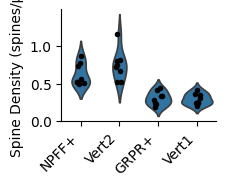

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scikit_posthocs as sp

# =============================
# CONFIG
# =============================
SAVE_SVG = True
SVG_PATH = "/Users/wangchu/connectivity_analysis/interneuron_matrix_figure4/vertical_spine_density.svg"

FIG_W_CM = 6
FIG_H_CM = 5
CM_TO_INCH = 1 / 2.54

ORDER = ["NPFF+", "Vert2", "GRPR+", "Vert1"]

# =============================
# Raw Data
# =============================

# NPFF+
npff_spines = np.array([20, 27, 18, 28, 37, 21, 19, 22])
npff_length = np.array([38.563, 36.467, 36.233, 35.888,
                        42.382, 40.246, 37.595, 39.697])

# GRPR+
grpr_spines = np.array([18, 12, 19, 16, 18, 19, 16, 14])
grpr_length = np.array([64.568, 65.092, 46.417, 48.590,
                        41.095, 57.061, 69.745, 58.544])

# Vert1  (kept exactly as you defined)
vert2_spines = np.array([30, 34, 25, 29, 36, 27, 63, 34])
vert2_length = np.array([44.504, 42.575, 47.642, 40.383,
                         69.669, 36.416, 54.343, 41.552])

# Vert2  (kept exactly as you defined)
vert1_spines = np.array([17, 30, 22, 15, 14, 12, 20, 25])
vert1_length = np.array([49.294, 72.155, 89.566, 73.823,
                         59.707, 32.883, 77.304, 80.097])

# =============================
# Compute spine density
# =============================

npff_density = npff_spines / npff_length
grpr_density = grpr_spines / grpr_length
vert1_density = vert1_spines / vert1_length
vert2_density = vert2_spines / vert2_length

# =============================
# Create DataFrame
# =============================

df = pd.DataFrame({
    "Spine Density (spines/µm)": np.concatenate([
        npff_density,
        vert2_density,
        grpr_density,
        vert1_density
    ]),
    "Group": (
        ["NPFF+"] * 8 +
        ["Vert2"] * 8 +
        ["GRPR+"] * 8 +
        ["Vert1"] * 8
    )
})

df["Group"] = pd.Categorical(df["Group"], categories=ORDER, ordered=True)

# =============================
# Kruskal–Wallis Test
# =============================

kw_stat, kw_p = st.kruskal(
    npff_density,
    vert2_density,
    grpr_density,
    vert1_density
)

print("Kruskal–Wallis test")
print("H statistic =", kw_stat)
print("p value =", kw_p)

# =============================
# Dunn Post Hoc (Bonferroni)
# =============================

dunn = sp.posthoc_dunn(
    df,
    val_col="Spine Density (spines/µm)",
    group_col="Group",
    p_adjust="bonferroni"
)

dunn = dunn.loc[ORDER, ORDER]

print("\nDunn post hoc (Bonferroni corrected p-values):")
print(dunn)

# =============================
# Mean ± SD
# =============================

print("\nMean ± SD (spines/µm)")
for name, arr in {
    "NPFF+": npff_density,
    "Vert2": vert2_density,
    "GRPR+": grpr_density,
    "Vert1": vert1_density
}.items():
    print(f"{name}: {np.mean(arr):.4f} ± {np.std(arr, ddof=1):.4f}")

# =============================
# Plot
# =============================

plt.figure(figsize=(FIG_W_CM * CM_TO_INCH, FIG_H_CM * CM_TO_INCH))

sns.violinplot(
    data=df,
    x="Group",
    y="Spine Density (spines/µm)",
    order=ORDER,
    inner=None
)

sns.stripplot(
    data=df,
    x="Group",
    y="Spine Density (spines/µm)",
    order=ORDER,
    color="black",
    size=4,
    jitter=True
)

plt.ylabel("Spine Density (spines/µm)")
plt.xlabel("")

# Rotate x labels 45° right
plt.xticks(rotation=45, ha="right")

# Remove top and right spines
sns.despine(top=True, right=True)

plt.tight_layout()

if SAVE_SVG:
    plt.savefig(SVG_PATH, format="svg")
    print("Saved to:", SVG_PATH)

plt.show()
